In [ ]:
%%file head.py

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


class HeadPreprocessConfig:
    def __init__(self):
        self.model_path = "/content/blaze_face_short_range.tflite"
        self.detection_threshold = 0.5

        self.head_width_scale = 1.30
        self.head_height_scale = 1.50
        self.head_vertical_shift = 0.12

        self.gray_fill_value = 128
        self.save_grayscale = True

        self.enable_adaptive_smoothing = True
        self.motion_scale = 20.0


class MediaPipeHeadDetector:
    def __init__(self, model_path, threshold=0.5):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceDetectorOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE,
            min_detection_confidence=0.2,
        )
        self.detector = vision.FaceDetector.create_from_options(options)
        self.threshold = threshold

    def detect(self, frame_bgr):
        try:
            if len(frame_bgr.shape) == 2:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_GRAY2RGB)
            else:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            result = self.detector.detect(mp_image)
        except Exception:
            return None

        if not result.detections:
            return None

        best_face = None
        best_area = -1

        for det in result.detections:
            score = float(det.categories[0].score)
            if score < self.threshold:
                continue

            bbox = det.bounding_box
            x1 = bbox.origin_x
            y1 = bbox.origin_y
            x2 = x1 + bbox.width
            y2 = y1 + bbox.height

            area = (x2 - x1) * (y2 - y1)
            if area > best_area:
                best_area = area
                best_face = {"bbox": [x1, y1, x2, y2]}

        return best_face

    def close(self):
        self.detector.close()


def get_fps_fallback_limits(fps):
    fps_int = int(round(fps)) if fps and fps > 0 else 30
    if fps_int == 30:
        return 4, 18
    return 2, 9


def ensure_gray(frame):
    if len(frame.shape) == 2:
        return frame
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


def compute_head_box_from_face(face, cfg):
    x1, y1, x2, y2 = face["bbox"]

    face_w = x2 - x1
    face_h = y2 - y1

    cx = x1 + face_w / 2.0
    cy = y1 + face_h / 2.0

    cy -= cfg.head_vertical_shift * face_h

    crop_w = int(face_w * cfg.head_width_scale)
    crop_h = int(face_h * cfg.head_height_scale)

    x1 = int(cx - crop_w / 2.0)
    y1 = int(cy - crop_h / 2.0)
    x2 = x1 + crop_w
    y2 = y1 + crop_h

    return [x1, y1, x2, y2]


def smooth_box(prev_box, curr_box, motion_scale=20.0):
    if prev_box is None:
        return [int(round(v)) for v in curr_box]

    prev = np.array(prev_box, dtype=np.float32)
    curr = np.array(curr_box, dtype=np.float32)

    movement = np.linalg.norm(curr - prev)
    motion_factor = min(1.0, movement / motion_scale)

    alpha = 0.7 - 0.4 * motion_factor
    smoothed = alpha * prev + (1.0 - alpha) * curr

    return [int(round(v)) for v in smoothed]


def crop_with_reflect_padding(img, x1, y1, x2, y2):
    x1 = int(round(x1))
    y1 = int(round(y1))
    x2 = int(round(x2))
    y2 = int(round(y2))

    h, w = img.shape[:2]

    pad_l = max(0, -x1)
    pad_t = max(0, -y1)
    pad_r = max(0, x2 - w)
    pad_b = max(0, y2 - h)

    if pad_l or pad_t or pad_r or pad_b:
        img = cv2.copyMakeBorder(
            img,
            pad_t,
            pad_b,
            pad_l,
            pad_r,
            borderType=cv2.BORDER_REFLECT
        )

    x1 += pad_l
    x2 += pad_l
    y1 += pad_t
    y2 += pad_t

    return img[y1:y2, x1:x2]


def extract_head_crop(frame, box, save_grayscale=True):
    if box is None:
        return None

    if save_grayscale:
        img = ensure_gray(frame)
    else:
        if len(frame.shape) == 2:
            img = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        else:
            img = frame

    crop = crop_with_reflect_padding(img, *box)

    if crop is None or crop.size == 0:
        return None

    return crop


def make_gray_from_box(box, cfg):
    if box is not None:
        x1, y1, x2, y2 = box
        h = max(1, int(round(y2 - y1)))
        w = max(1, int(round(x2 - x1)))

        if cfg.save_grayscale:
            return np.full((h, w), cfg.gray_fill_value, dtype=np.uint8)
        return np.full((h, w, 3), cfg.gray_fill_value, dtype=np.uint8)

    if cfg.save_grayscale:
        return np.full((32, 32), cfg.gray_fill_value, dtype=np.uint8)
    return np.full((32, 32, 3), cfg.gray_fill_value, dtype=np.uint8)


class OnlineHeadCropper:
    def __init__(self, cfg, max_prev_crop, max_prev_position):
        self.cfg = cfg
        self.max_prev_crop = max_prev_crop
        self.max_prev_position = max_prev_position

        self.prev_crop = None
        self.prev_box = None
        self.prev_real_box = None
        self.missing_count = 0

    def step(self, frame, face):
        if face is not None and "bbox" in face:
            raw_box = compute_head_box_from_face(face, self.cfg)

            if self.cfg.enable_adaptive_smoothing:
                box = smooth_box(
                    self.prev_real_box,
                    raw_box,
                    motion_scale=self.cfg.motion_scale
                )
            else:
                box = [int(round(v)) for v in raw_box]

            crop = extract_head_crop(frame, box, self.cfg.save_grayscale)

            if crop is not None:
                self.prev_crop = crop.copy()
                self.prev_box = box
                self.prev_real_box = raw_box
                self.missing_count = 0
                return crop, 1, "detected"

        self.missing_count += 1

        if self.prev_crop is not None and self.missing_count <= self.max_prev_crop:
            return self.prev_crop.copy(), 0, "prev_crop"

        if self.prev_box is not None and self.missing_count <= self.max_prev_position:
            crop = extract_head_crop(frame, self.prev_box, self.cfg.save_grayscale)
            if crop is not None:
                return crop, 0, "prev_position"

        return make_gray_from_box(self.prev_box, self.cfg), 0, "gray"


def preprocess_head_sequence(frames, model_path, fps=30, cfg=None, return_metadata=False):
    """
    frames: list of numpy images
    model_path: path to blaze_face_short_range.tflite
    fps: used only for fallback limits

    returns:
        crops
    or
        crops, metadata
    """
    if cfg is None:
        cfg = HeadPreprocessConfig()

    cfg.model_path = model_path

    detector = MediaPipeHeadDetector(
        model_path=cfg.model_path,
        threshold=cfg.detection_threshold
    )

    max_prev_crop, max_prev_position = get_fps_fallback_limits(fps)
    cropper = OnlineHeadCropper(cfg, max_prev_crop, max_prev_position)

    crops = []
    metadata = []

    try:
        for frame_idx, frame in enumerate(frames):
            face = detector.detect(frame)
            crop, validity_mask, status = cropper.step(frame, face)

            crops.append(crop)
            metadata.append({
                "frame_idx": frame_idx,
                "validity_mask": validity_mask,
                "status": status
            })
    finally:
        detector.close()

    if return_metadata:
        return crops, metadata

    return crops

Writing head.py


In [ ]:
%%file eye.py


import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


class EyePreprocessConfig:
    def __init__(self):
        self.model_path = "/content/face_landmarker.task"
        self.region = "right_eye"

        self.num_faces = 1
        self.min_face_detection_confidence = 0.2
        self.min_face_presence_confidence = 0.2
        self.min_tracking_confidence = 0.2

        self.padding_ratio = 0.40
        self.min_eye_size = 45

        self.gray_fill_value = 128

        self.enable_adaptive_smoothing = True
        self.motion_scale = 20.0


class MediaPipeTasksDetector:
    def __init__(
        self,
        model_path,
        num_faces=1,
        min_face_detection_confidence=0.2,
        min_face_presence_confidence=0.2,
        min_tracking_confidence=0.2,
    ):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE,
            num_faces=num_faces,
            min_face_detection_confidence=min_face_detection_confidence,
            min_face_presence_confidence=min_face_presence_confidence,
            min_tracking_confidence=min_tracking_confidence,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
        )
        self.detector = vision.FaceLandmarker.create_from_options(options)

        self.left_eye_indices = [33, 133, 160, 159, 158, 157, 173, 246, 161, 144, 145, 153, 154, 155]
        self.right_eye_indices = [362, 263, 387, 386, 385, 384, 398, 466, 388, 373, 374, 380, 381, 382]

    def close(self):
        self.detector.close()

    def detect(self, frame_bgr):
        h, w = frame_bgr.shape[:2]

        try:
            if len(frame_bgr.shape) == 2:
                rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_GRAY2RGB)
            else:
                rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = self.detector.detect(mp_image)
        except Exception:
            return None

        if not result.face_landmarks:
            return None

        face_landmarks = result.face_landmarks[0]

        def point(idx):
            lm = face_landmarks[idx]
            return float(lm.x * w), float(lm.y * h)

        left_eye_points = [point(i) for i in self.left_eye_indices]
        right_eye_points = [point(i) for i in self.right_eye_indices]

        left_eye_center = (
            float(np.mean([p[0] for p in left_eye_points])),
            float(np.mean([p[1] for p in left_eye_points])),
        )
        right_eye_center = (
            float(np.mean([p[0] for p in right_eye_points])),
            float(np.mean([p[1] for p in right_eye_points])),
        )

        xs = [p[0] for p in left_eye_points + right_eye_points]
        ys = [p[1] for p in left_eye_points + right_eye_points]

        return {
            "facial_area": [min(xs), min(ys), max(xs), max(ys)],
            "landmarks": {
                "left_eye": left_eye_center,
                "right_eye": right_eye_center,
                "left_eye_points": left_eye_points,
                "right_eye_points": right_eye_points,
            },
        }


def ensure_gray(frame):
    if len(frame.shape) == 2:
        return frame
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


def crop_with_replicate_padding(img, x1, y1, x2, y2):
    h, w = img.shape[:2]

    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - w)
    pad_bottom = max(0, y2 - h)

    if pad_left or pad_top or pad_right or pad_bottom:
        img = cv2.copyMakeBorder(
            img,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_REPLICATE
        )

    x1 += pad_left
    x2 += pad_left
    y1 += pad_top
    y2 += pad_top

    return img[y1:y2, x1:x2]


def compute_square_eye_box(eye_points, padding_ratio, min_size):
    xs = [p[0] for p in eye_points]
    ys = [p[1] for p in eye_points]

    x_min = min(xs)
    x_max = max(xs)
    y_min = min(ys)
    y_max = max(ys)

    center_x = (x_min + x_max) / 2.0
    center_y = (y_min + y_max) / 2.0

    eye_w = x_max - x_min
    eye_h = y_max - y_min
    size = max(eye_w, eye_h)

    size = size * (1.0 + padding_ratio)
    size = max(size, float(min_size))

    half_size = size / 2.0

    x1 = center_x - half_size
    y1 = center_y - half_size
    x2 = center_x + half_size
    y2 = center_y + half_size

    return [x1, y1, x2, y2]


def smooth_box(prev_box, curr_box, motion_scale=20.0):
    if prev_box is None:
        return [float(v) for v in curr_box]

    prev = np.array(prev_box, dtype=np.float32)
    curr = np.array(curr_box, dtype=np.float32)

    movement = np.linalg.norm(curr - prev)
    motion_factor = min(1.0, movement / motion_scale)

    alpha = 0.7 - 0.4 * motion_factor
    smoothed = alpha * prev + (1.0 - alpha) * curr

    return smoothed.astype(np.float32).tolist()


def make_gray_from_box(box, gray_fill_value, min_eye_size):
    if box is not None:
        x1, y1, x2, y2 = box
        h = max(1, int(round(y2 - y1)))
        w = max(1, int(round(x2 - x1)))
        return np.full((h, w), gray_fill_value, dtype=np.uint8)

    size = max(1, int(round(min_eye_size)))
    return np.full((size, size), gray_fill_value, dtype=np.uint8)


class EyePreprocessor:
    def __init__(self, cfg):
        self.region = cfg.region
        self.padding_ratio = cfg.padding_ratio
        self.min_eye_size = cfg.min_eye_size
        self.enable_adaptive_smoothing = cfg.enable_adaptive_smoothing
        self.motion_scale = cfg.motion_scale
        self.gray_fill_value = cfg.gray_fill_value

        self.prev_real_box = None
        self.prev_valid_crop = None
        self.prev_valid_box = None

        self.prev_crop_used_consecutively = 0
        self.prev_position_used_consecutively = 0

    def reset_video_state(self):
        self.prev_real_box = None
        self.prev_valid_crop = None
        self.prev_valid_box = None
        self.prev_crop_used_consecutively = 0
        self.prev_position_used_consecutively = 0

    def get_limits(self, fps):
        if int(round(fps)) == 30:
            return 4, 18
        return 2, 9

    def extract_valid_crop(self, frame, face):
        if face is None or "landmarks" not in face:
            return None

        landmarks = face["landmarks"]
        eye_points = landmarks["left_eye_points"] if self.region == "left_eye" else landmarks["right_eye_points"]

        raw_box = compute_square_eye_box(
            eye_points,
            self.padding_ratio,
            self.min_eye_size
        )

        if self.enable_adaptive_smoothing:
            box = smooth_box(self.prev_real_box, raw_box, self.motion_scale)
        else:
            box = raw_box

        x1, y1, x2, y2 = [int(round(v)) for v in box]

        gray_frame = ensure_gray(frame)
        crop = crop_with_replicate_padding(gray_frame, x1, y1, x2, y2)

        if crop is None or crop.size == 0:
            return None

        box_int = [x1, y1, x2, y2]

        self.prev_real_box = box_int
        self.prev_valid_crop = crop.copy()
        self.prev_valid_box = box_int
        self.prev_crop_used_consecutively = 0
        self.prev_position_used_consecutively = 0

        return crop, 1, "detected"

    def extract_with_fallback(self, frame, face, fps):
        prev_crop_limit, prev_pos_limit = self.get_limits(fps)

        valid_result = self.extract_valid_crop(frame, face)
        if valid_result is not None:
            return valid_result

        if self.prev_valid_crop is not None and self.prev_crop_used_consecutively < prev_crop_limit:
            self.prev_crop_used_consecutively += 1
            self.prev_position_used_consecutively = 0
            return self.prev_valid_crop.copy(), 0, "prev_crop"

        if self.prev_valid_box is not None and self.prev_position_used_consecutively < prev_pos_limit:
            x1, y1, x2, y2 = self.prev_valid_box
            gray_frame = ensure_gray(frame)
            crop = crop_with_replicate_padding(gray_frame, x1, y1, x2, y2)
            self.prev_position_used_consecutively += 1
            self.prev_crop_used_consecutively = 0
            return crop, 0, "prev_position"

        gray_crop = make_gray_from_box(
            self.prev_valid_box,
            self.gray_fill_value,
            self.min_eye_size
        )
        return gray_crop, 0, "gray"


def preprocess_eye_sequence(frames, model_path, fps=30, region="right_eye", return_metadata=False):
    cfg = EyePreprocessConfig()
    cfg.model_path = model_path
    cfg.region = region

    detector = MediaPipeTasksDetector(
        model_path=cfg.model_path,
        num_faces=cfg.num_faces,
        min_face_detection_confidence=cfg.min_face_detection_confidence,
        min_face_presence_confidence=cfg.min_face_presence_confidence,
        min_tracking_confidence=cfg.min_tracking_confidence,
    )

    cropper = EyePreprocessor(cfg)
    cropper.reset_video_state()

    crops = []
    metadata = []

    try:
        for frame_idx, frame in enumerate(frames):
            face = detector.detect(frame)
            crop, validity, mode = cropper.extract_with_fallback(frame, face, fps)

            crops.append(crop)
            metadata.append({
                "frame_idx": frame_idx,
                "validity_mask": validity,
                "status": mode,
            })
    finally:
        detector.close()

    if return_metadata:
        return crops, metadata

    return crops

Writing eye.py


In [ ]:
%%file mouth.py

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


class MouthPreprocessConfig:
    def __init__(self):
        self.model_path = "/content/face_landmarker.task"
        self.detection_threshold = 0.2

        self.gray_fill_value = 128
        self.save_grayscale = True

        self.enable_adaptive_smoothing = True
        self.motion_scale = 20.0

        self.mouth_width_scale = 1.45
        self.mouth_height_scale = 2.5
        self.mouth_vertical_shift = 0.03


class FaceMouthLandmarkDetector:
    def __init__(self, model_path, threshold=0.2):
        self.threshold = threshold

        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE,
            num_faces=1,
            min_face_detection_confidence=threshold,
            min_face_presence_confidence=threshold,
            min_tracking_confidence=threshold,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(options)

        self.mouth_indices = [
            61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291,
            78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
            191, 80, 81, 82, 13, 312, 311, 310, 415
        ]

    def detect(self, frame_bgr):
        try:
            h, w = frame_bgr.shape[:2]

            if len(frame_bgr.shape) == 2:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_GRAY2RGB)
            else:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            result = self.landmarker.detect(mp_image)
        except Exception:
            return None

        if not result.face_landmarks:
            return None

        face_landmarks = result.face_landmarks[0]

        def pt(idx):
            return (
                float(face_landmarks[idx].x * w),
                float(face_landmarks[idx].y * h)
            )

        mouth_points = [pt(idx) for idx in self.mouth_indices]

        return {
            "score": 1.0,
            "landmarks": {
                "left_eye": pt(33),
                "right_eye": pt(263),
                "nose": pt(1),
                "mouth_left": pt(61),
                "mouth_right": pt(291),
                "mouth_points": mouth_points,
            }
        }

    def close(self):
        self.landmarker.close()


def get_fps_fallback_limits(fps):
    fps_int = int(round(fps)) if fps and fps > 0 else 30
    if fps_int == 30:
        return 4, 18
    return 2, 9


def crop_with_padding(img, x1, y1, x2, y2):
    x1 = int(round(x1))
    y1 = int(round(y1))
    x2 = int(round(x2))
    y2 = int(round(y2))

    h, w = img.shape[:2]

    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - w)
    pad_bottom = max(0, y2 - h)

    if pad_left or pad_top or pad_right or pad_bottom:
        img = cv2.copyMakeBorder(
            img,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_REPLICATE
        )

    x1 += pad_left
    x2 += pad_left
    y1 += pad_top
    y2 += pad_top

    return img[y1:y2, x1:x2]


def is_valid_mouth(landmarks):
    points = landmarks.get("mouth_points")
    nose = np.array(landmarks["nose"], dtype=np.float32)

    if not points or len(points) < 4:
        return False

    pts = np.array(points, dtype=np.float32)
    min_xy = pts.min(axis=0)
    max_xy = pts.max(axis=0)

    width = float(max_xy[0] - min_xy[0])
    height = float(max_xy[1] - min_xy[1])
    center = pts.mean(axis=0)
    mouth_to_nose = np.linalg.norm(center - nose)

    if width < 10:
        return False
    if height < 4:
        return False
    if mouth_to_nose < 5:
        return False

    return True


def compute_mouth_box_from_landmarks(landmarks, cfg):
    pts = np.array(landmarks["mouth_points"], dtype=np.float32)

    min_x = pts[:, 0].min()
    max_x = pts[:, 0].max()
    min_y = pts[:, 1].min()
    max_y = pts[:, 1].max()

    mouth_width = max_x - min_x
    mouth_height = max_y - min_y

    cx = (min_x + max_x) / 2.0
    cy = (min_y + max_y) / 2.0

    cy += mouth_height * cfg.mouth_vertical_shift

    scaled_w = max(mouth_width * cfg.mouth_width_scale, 12)
    scaled_h = max(mouth_height * cfg.mouth_height_scale, 12)

    side = int(round(max(scaled_w, scaled_h)))

    x1 = int(round(cx - side / 2.0))
    y1 = int(round(cy - side / 2.0))
    x2 = x1 + side
    y2 = y1 + side

    return [x1, y1, x2, y2]


def smooth_box(prev_box, curr_box, motion_scale=20.0):
    if prev_box is None:
        return [int(round(v)) for v in curr_box]

    prev = np.array(prev_box, dtype=np.float32)
    curr = np.array(curr_box, dtype=np.float32)

    movement = np.linalg.norm(curr - prev)
    motion_factor = min(1.0, movement / motion_scale)

    alpha = 0.7 - 0.4 * motion_factor
    smoothed = alpha * prev + (1.0 - alpha) * curr

    return [int(round(v)) for v in smoothed]


def extract_crop(frame, box, save_grayscale=True):
    if box is None:
        return None

    x1, y1, x2, y2 = box

    if save_grayscale:
        if len(frame.shape) == 2:
            img = frame
        else:
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        if len(frame.shape) == 2:
            img = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        else:
            img = frame

    crop = crop_with_padding(img, x1, y1, x2, y2)

    if crop.size == 0:
        return None

    return crop


def make_gray_from_box(box, cfg):
    if box is not None:
        x1, y1, x2, y2 = box
        h = max(1, int(round(y2 - y1)))
        w = max(1, int(round(x2 - x1)))

        if cfg.save_grayscale:
            return np.full((h, w), cfg.gray_fill_value, dtype=np.uint8)
        return np.full((h, w, 3), cfg.gray_fill_value, dtype=np.uint8)

    if cfg.save_grayscale:
        return np.full((32, 32), cfg.gray_fill_value, dtype=np.uint8)
    return np.full((32, 32, 3), cfg.gray_fill_value, dtype=np.uint8)


class OnlineMouthCropper:
    def __init__(self, cfg, max_prev_crop, max_prev_position):
        self.cfg = cfg
        self.max_prev_crop = max_prev_crop
        self.max_prev_position = max_prev_position

        self.prev_crop = None
        self.prev_box = None
        self.prev_real_box = None
        self.missing_count = 0

    def step(self, frame, face):
        if face is not None and is_valid_mouth(face["landmarks"]):
            raw_box = compute_mouth_box_from_landmarks(face["landmarks"], self.cfg)

            if self.cfg.enable_adaptive_smoothing:
                box = smooth_box(
                    self.prev_real_box,
                    raw_box,
                    motion_scale=self.cfg.motion_scale
                )
            else:
                box = [int(round(v)) for v in raw_box]

            crop = extract_crop(frame, box, self.cfg.save_grayscale)

            if crop is not None:
                self.prev_crop = crop
                self.prev_box = box
                self.prev_real_box = raw_box
                self.missing_count = 0
                return crop, 1, "detected"

        self.missing_count += 1

        if self.prev_crop is not None and self.missing_count <= self.max_prev_crop:
            return self.prev_crop.copy(), 0, "prev_crop"

        if self.prev_box is not None and self.missing_count <= self.max_prev_position:
            crop = extract_crop(frame, self.prev_box, self.cfg.save_grayscale)
            if crop is not None:
                return crop, 0, "prev_position"

        return make_gray_from_box(self.prev_box, self.cfg), 0, "gray"


def preprocess_mouth_sequence(frames, model_path, fps=30, cfg=None, return_metadata=False):
    """
    frames: list of numpy images
    model_path: path to face_landmarker.task
    fps: used only for fallback limits

    returns:
        crops
    or
        crops, metadata
    """
    if cfg is None:
        cfg = MouthPreprocessConfig()

    cfg.model_path = model_path

    detector = FaceMouthLandmarkDetector(
        model_path=cfg.model_path,
        threshold=cfg.detection_threshold
    )

    max_prev_crop, max_prev_position = get_fps_fallback_limits(fps)
    cropper = OnlineMouthCropper(cfg, max_prev_crop, max_prev_position)

    crops = []
    metadata = []

    try:
        for frame_idx, frame in enumerate(frames):
            face = detector.detect(frame)
            crop, validity_mask, status = cropper.step(frame, face)

            crops.append(crop)
            metadata.append({
                "frame_idx": frame_idx,
                "validity_mask": validity_mask,
                "status": status
            })
    finally:
        detector.close()

    if return_metadata:
        return crops, metadata

    return crops

Writing mouth.py


In [ ]:
import os
!uv pip install -q kaggle


os.environ["KAGGLE_USERNAME"] = "manith04"
os.environ["KAGGLE_KEY"] = "KGAT_28e717b9ccd1d5f6908afdf6559d8cb4"
os.environ["KAGGLE_API_TOKEN"] = "KGAT_28e717b9ccd1d5f6908afdf6559d8cb4"

!mkdir -p /content/dataset1


# !kaggle datasets download -d manith04/ddd -p /content/dataset1 --unzip
# !kaggle datasets download -d manith04/ddewewewee -p /content/dataset1 --unzip
# !kaggle datasets download -d manith04/gdgdfhfg -p /content/dataset1 --unzip



# !kaggle datasets download -d manith04/ddd        -p /content/dataset1 --unzip
# !kaggle datasets download -d manith04/ddewewewee -p /content/dataset1 --unzip
!kaggle datasets download -d manith04/gdgdfhfg -p /content/dataset1 --unzip
# !kaggle datasets download   -d manith04/ky87retdgfu7t -p /content/dataset1 --unzip


print("Download complete.")
!uv pip install mediapipe
!wget https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/latest/blaze_face_short_range.tflite
!wget https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task
!kaggle models variations versions files manith04/ddd-manith-bbb/pyTorch/default/2

Dataset URL: https://www.kaggle.com/datasets/manith04/gdgdfhfg
License(s): MIT
100% 236M/236M [00:01<00:00, 144MB/s]

Download complete.
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 710ms
Prepared 3 packages in 384ms
Uninstalled 1 package in 28ms
Installed 3 packages in 66ms
 - absl-py==1.4.0
 + absl-py==2.4.0
 + mediapipe==0.10.33
 + sounddevice==0.5.5
--2026-04-19 13:20:31--  https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/latest/blaze_face_short_range.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.184.207, 173.194.193.207, 173.194.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.184.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 229746 (224K) [application/octet-stream]
Saving to: ‘blaze_face_short_range.tflite’

blaze_face_short_ra 100%[===================>] 224.36K  --.-KB/s    in 0.005s  

2026-04-19 13:20:31 (47.7 MB/s) - 

Device: cpu
Models loaded successfully
Video FPS: 29.97


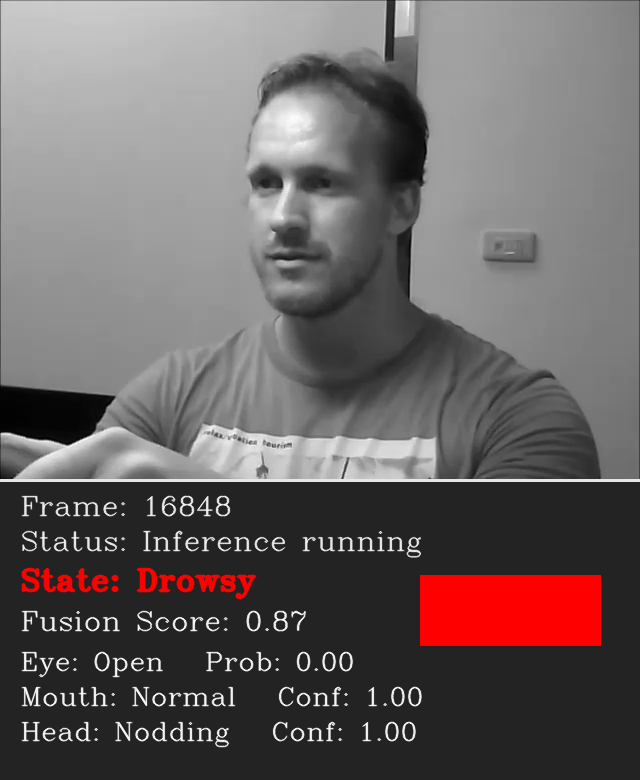

Finished live inference.


In [ ]:
import cv2
import time
import numpy as np
import torch
import torch.nn as nn
import timm
from collections import deque
from PIL import Image
from IPython.display import display

from eye import preprocess_eye_sequence
from mouth import preprocess_mouth_sequence
from head import preprocess_head_sequence


FACE_LANDMARKER_PATH = "/content/face_landmarker.task"
BLAZE_FACE_PATH = "/content/blaze_face_short_range.tflite"

EYE_MODEL_PATH = "/content/best_val_accuracy_righteye_model.pth"
MOUTH_MODEL_PATH = "/content/best_val_accuracy_mouth_model.pth"
HEAD_MODEL_PATH = "/content/best_val_accuracy_head_model.pth"
FUSION_MODEL_PATH = "/content/best_drowsiness_fusion_model.pth"

INPUT_VIDEO_PATH = "/content/dataset1/022/022_noglasses_mix.mp4"

device = torch.device("cpu")
print("Device:", device)


EYE_CLASS_NAMES = {
    0: "Open",
    1: "Closed"
}

MOUTH_CLASS_NAMES = {
    0: "Normal",
    1: "Yawning",
    2: "Talking/Laughing"
}

HEAD_CLASS_NAMES = {
    0: "Normal",
    1: "Nodding",
    2: "Looking Aside"
}


class EnhancementBlock(nn.Module):
    def __init__(self, channels=1, hidden_channels=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=4, num_channels=hidden_channels),
            nn.GELU(),
            nn.Conv2d(hidden_channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        enhanced = self.block(x)
        return x + 0.1 * enhanced


class CNNEncoder(nn.Module):
    def __init__(self, encoder_backbone_name, encoder_output_dim, encoder_dropout):
        super().__init__()

        self.enhancer = EnhancementBlock(channels=1, hidden_channels=8)

        self.backbone = timm.create_model(
            encoder_backbone_name,
            pretrained=True,
            in_chans=1,
            num_classes=0,
            global_pool=""
        )

        for param in self.backbone.parameters():
            param.requires_grad = True

        if hasattr(self.backbone, "conv_head"):
            for param in self.backbone.conv_head.parameters():
                param.requires_grad = False

        backbone_output_dim = self.backbone.num_features

        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(backbone_output_dim, encoder_output_dim),
            nn.LayerNorm(encoder_output_dim),
            nn.GELU(),
            nn.Dropout(encoder_dropout),
        )

    def forward(self, x):
        x = self.enhancer(x)
        x = self.backbone.forward_features(x)

        if x.ndim == 4:
            x = self.pool(x)
        elif x.ndim == 2:
            pass
        else:
            raise ValueError(f"Unexpected feature shape: {x.shape}")

        x = self.fc(x)
        return x


class LSTM(nn.Module):
    def __init__(
        self,
        encoder_backbone_name,
        encoder_output_dim,
        encoder_dropout,
        lstm_hidden_dim,
        num_classes,
        lstm_num_layers,
        temporal_dropout,
        proj_size=0
    ):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = num_classes == 1

        self.encoder = CNNEncoder(
            encoder_backbone_name=encoder_backbone_name,
            encoder_output_dim=encoder_output_dim,
            encoder_dropout=encoder_dropout,
        )

        self.lstm = nn.LSTM(
            input_size=encoder_output_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_num_layers,
            batch_first=True,
            dropout=temporal_dropout if lstm_num_layers > 1 else 0.0,
            proj_size=proj_size,
        )

        final_dim = proj_size if proj_size > 0 else lstm_hidden_dim
        self.classifier = nn.Linear(final_dim * 2, num_classes)

    def forward_features(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        features = self.encoder(x)
        features = features.view(B, T, -1)

        lstm_out, _ = self.lstm(features)
        last_timestep = lstm_out[:, -2:, :]
        last_timestep = last_timestep.reshape(B, -1)
        return last_timestep

    def forward(self, x):
        last_timestep = self.forward_features(x)
        logits = self.classifier(last_timestep)

        if self.is_binary:
            return logits.squeeze(1)
        return logits


class FusionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


ENCODER_BACKBONE_NAME = "mobilenetv3_small_100"
ENCODER_OUTPUT_DIM = 288
ENCODER_DROPOUT = 0.2
LSTM_HIDDEN_DIM = 288
LSTM_NUM_LAYERS = 2
TEMPORAL_DROPOUT = 0.2
PROJ_SIZE = 0

EYE_NUM_CLASSES = 1
MOUTH_NUM_CLASSES = 3
HEAD_NUM_CLASSES = 3

FINAL_DIM = PROJ_SIZE if PROJ_SIZE > 0 else LSTM_HIDDEN_DIM
BRANCH_FEATURE_DIM = FINAL_DIM * 2
FUSION_INPUT_DIM = BRANCH_FEATURE_DIM * 3


eye_model = LSTM(
    encoder_backbone_name=ENCODER_BACKBONE_NAME,
    encoder_output_dim=ENCODER_OUTPUT_DIM,
    encoder_dropout=ENCODER_DROPOUT,
    lstm_hidden_dim=LSTM_HIDDEN_DIM,
    num_classes=EYE_NUM_CLASSES,
    lstm_num_layers=LSTM_NUM_LAYERS,
    temporal_dropout=TEMPORAL_DROPOUT,
    proj_size=PROJ_SIZE
)

mouth_model = LSTM(
    encoder_backbone_name=ENCODER_BACKBONE_NAME,
    encoder_output_dim=ENCODER_OUTPUT_DIM,
    encoder_dropout=ENCODER_DROPOUT,
    lstm_hidden_dim=LSTM_HIDDEN_DIM,
    num_classes=MOUTH_NUM_CLASSES,
    lstm_num_layers=LSTM_NUM_LAYERS,
    temporal_dropout=TEMPORAL_DROPOUT,
    proj_size=PROJ_SIZE
)

head_model = LSTM(
    encoder_backbone_name=ENCODER_BACKBONE_NAME,
    encoder_output_dim=ENCODER_OUTPUT_DIM,
    encoder_dropout=ENCODER_DROPOUT,
    lstm_hidden_dim=LSTM_HIDDEN_DIM,
    num_classes=HEAD_NUM_CLASSES,
    lstm_num_layers=LSTM_NUM_LAYERS,
    temporal_dropout=TEMPORAL_DROPOUT,
    proj_size=PROJ_SIZE
)

fusion_model = FusionMLP(input_dim=FUSION_INPUT_DIM)


eye_checkpoint = torch.load(EYE_MODEL_PATH, map_location=device)
mouth_checkpoint = torch.load(MOUTH_MODEL_PATH, map_location=device)
head_checkpoint = torch.load(HEAD_MODEL_PATH, map_location=device)
fusion_checkpoint = torch.load(FUSION_MODEL_PATH, map_location=device)

eye_model.load_state_dict(eye_checkpoint["model_state_dict"])
mouth_model.load_state_dict(mouth_checkpoint["model_state_dict"])
head_model.load_state_dict(head_checkpoint["model_state_dict"])
fusion_model.load_state_dict(fusion_checkpoint["model_state_dict"])

eye_model = eye_model.to(device).eval()
mouth_model = mouth_model.to(device).eval()
head_model = head_model.to(device).eval()
fusion_model = fusion_model.to(device).eval()

print("Models loaded successfully")


def resize_crop_list(crops, size):
    resized_crops = []
    for crop in crops:
        resized = cv2.resize(crop, size)
        resized_crops.append(resized)
    return resized_crops


def crops_to_tensor(crops):
    arr = np.stack(crops, axis=0).astype(np.float32)
    arr = (arr / 127.5) - 1.0
    arr = np.expand_dims(arr, axis=1)
    arr = np.expand_dims(arr, axis=0)
    return torch.tensor(arr, dtype=torch.float32)


def bgr_to_pil(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(frame_rgb)


class DDDInferenceSequenceBuilder:
    def __init__(self, time_window_in_seconds, frames_per_window, window_stride_by_seconds=1):
        self.time_window_in_seconds = time_window_in_seconds
        self.frames_per_window = frames_per_window
        self.window_stride_by_seconds = window_stride_by_seconds

    def _get_sample_indices(self, available_frames_per_window):
        if self.frames_per_window == 1:
            return [available_frames_per_window - 1]

        frame_spacing = (available_frames_per_window - 1) / (self.frames_per_window - 1)

        indices = [
            round(i * frame_spacing)
            for i in range(self.frames_per_window)
        ]

        for i in range(1, len(indices)):
            if indices[i] <= indices[i - 1]:
                indices[i] = indices[i - 1] + 1

        return indices

    def build_sequence_from_buffer(self, frame_buffer, fps):
        available_frames_per_window = round(self.time_window_in_seconds * fps)

        if len(frame_buffer) < available_frames_per_window:
            return None

        latest_window_frames = list(frame_buffer)[-available_frames_per_window:]
        selected_indices = self._get_sample_indices(available_frames_per_window)

        if selected_indices[-1] >= len(latest_window_frames):
            return None

        sequence_frames = [latest_window_frames[i] for i in selected_indices]
        return sequence_frames


def sequence_processor(sequence_frames, fps=30):
    eye_crops = preprocess_eye_sequence(
        frames=sequence_frames,
        model_path=FACE_LANDMARKER_PATH,
        fps=fps,
        region="right_eye"
    )

    mouth_crops = preprocess_mouth_sequence(
        frames=sequence_frames,
        model_path=FACE_LANDMARKER_PATH,
        fps=fps
    )

    head_crops = preprocess_head_sequence(
        frames=sequence_frames,
        model_path=BLAZE_FACE_PATH,
        fps=fps
    )

    eye_crops = resize_crop_list(eye_crops, (112, 112))
    mouth_crops = resize_crop_list(mouth_crops, (112, 112))
    head_crops = resize_crop_list(head_crops, (112, 112))

    eye_tensor = crops_to_tensor(eye_crops).to(device)
    mouth_tensor = crops_to_tensor(mouth_crops).to(device)
    head_tensor = crops_to_tensor(head_crops).to(device)

    with torch.no_grad():
        eye_features = eye_model.forward_features(eye_tensor)
        mouth_features = mouth_model.forward_features(mouth_tensor)
        head_features = head_model.forward_features(head_tensor)

        eye_logits = eye_model.classifier(eye_features)
        mouth_logits = mouth_model.classifier(mouth_features)
        head_logits = head_model.classifier(head_features)

        eye_prob = torch.sigmoid(eye_logits).squeeze().item()
        eye_pred_class = 1 if eye_prob >= 0.5 else 0

        mouth_probs = torch.softmax(mouth_logits, dim=1)
        head_probs = torch.softmax(head_logits, dim=1)

        mouth_prob = mouth_probs.max(dim=1).values.item()
        head_prob = head_probs.max(dim=1).values.item()

        mouth_pred_class = mouth_probs.argmax(dim=1).item()
        head_pred_class = head_probs.argmax(dim=1).item()

        fusion_input = torch.cat(
            [eye_features, mouth_features, head_features],
            dim=1
        )

        fusion_logits = fusion_model(fusion_input)
        fusion_prob = torch.sigmoid(fusion_logits).squeeze().item()

    state_text = "Drowsy" if fusion_prob >= 0.5 else "Not Drowsy"

    return {
        "fusion_prob": fusion_prob,
        "state_text": state_text,
        "eye_prob": eye_prob,
        "eye_pred_class": eye_pred_class,
        "mouth_prob": mouth_prob,
        "head_prob": head_prob,
        "mouth_pred_class": mouth_pred_class,
        "head_pred_class": head_pred_class,
    }


def draw_panel(
    frame,
    frame_idx,
    current_score,
    current_state,
    waiting_for_sequence,
    eye_prob=0.0,
    eye_pred_class=0,
    mouth_prob=0.0,
    head_prob=0.0,
    mouth_pred_class=0,
    head_pred_class=0
):
    height, width = frame.shape[:2]
    panel_height = 300
    output_height = height + panel_height

    canvas = np.zeros((output_height, width, 3), dtype=np.uint8)
    canvas[:height] = frame

    cv2.rectangle(canvas, (0, height), (width, output_height), (35, 35, 35), -1)
    cv2.line(canvas, (0, height), (width, height), (230, 230, 230), 2)

    if waiting_for_sequence:
        status_line = "Waiting for full sequence"
        display_score = 0.0
        display_state = "Not Drowsy"
        eye_display = 0.0
        eye_class_display = "Open"
        mouth_display = 0.0
        head_display = 0.0
        mouth_class_display = "Normal"
        head_class_display = "Normal"
    else:
        status_line = "Inference running"
        display_score = current_score
        display_state = current_state
        eye_display = eye_prob
        eye_class_display = EYE_CLASS_NAMES.get(eye_pred_class, str(eye_pred_class))
        mouth_display = mouth_prob
        head_display = head_prob
        mouth_class_display = MOUTH_CLASS_NAMES.get(mouth_pred_class, str(mouth_pred_class))
        head_class_display = HEAD_CLASS_NAMES.get(head_pred_class, str(head_pred_class))

    font_main = cv2.FONT_HERSHEY_TRIPLEX
    font_small = cv2.FONT_HERSHEY_COMPLEX
    line_type = cv2.LINE_AA

    cv2.putText(canvas, f"Frame: {frame_idx}", (20, height + 35),
                font_small, 0.9, (245, 245, 245), 1, line_type)

    cv2.putText(canvas, f"Status: {status_line}", (20, height + 70),
                font_small, 0.9, (245, 245, 245), 1, line_type)

    state_color = (0, 0, 255) if display_state == "Drowsy" else (0, 255, 0)

    cv2.putText(canvas, f"State: {display_state}", (20, height + 110),
                font_main, 1.0, state_color, 2, line_type)

    cv2.putText(canvas, f"Fusion Score: {display_score:.2f}", (20, height + 150),
                font_small, 0.9, (255, 255, 255), 1, line_type)

    cv2.putText(canvas, f"Eye: {eye_class_display}   Prob: {eye_display:.2f}", (20, height + 190),
                font_small, 0.85, (255, 255, 255), 1, line_type)

    cv2.putText(canvas, f"Mouth: {mouth_class_display}   Conf: {mouth_display:.2f}", (20, height + 225),
                font_small, 0.85, (255, 255, 255), 1, line_type)

    cv2.putText(canvas, f"Head: {head_class_display}   Conf: {head_display:.2f}", (20, height + 260),
                font_small, 0.85, (255, 255, 255), 1, line_type)

    box_x1 = width - 220
    box_y1 = height + 95
    box_x2 = width - 40
    box_y2 = height + 165

    cv2.rectangle(canvas, (box_x1, box_y1), (box_x2, box_y2), state_color, -1)

    return canvas


def run_live_video_inference_colab_smoother(
    input_path,
    time_window_in_seconds,
    frames_per_window,
    window_stride_by_seconds=1,
    display_every_n_frames=1,
    sleep_time=0.0
):
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print("Could not open video")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25

    print("Video FPS:", fps)

    sequence_builder = DDDInferenceSequenceBuilder(
        time_window_in_seconds=time_window_in_seconds,
        frames_per_window=frames_per_window,
        window_stride_by_seconds=window_stride_by_seconds
    )

    available_frames_per_window = round(time_window_in_seconds * fps)
    stride_between_windows_in_frames = max(1, round(window_stride_by_seconds * fps))

    frame_buffer = deque(maxlen=available_frames_per_window)

    frame_idx = 0
    last_sequence_frame_idx = -stride_between_windows_in_frames

    current_score = 0.0
    current_state = "Not Drowsy"
    current_eye_prob = 0.0
    current_eye_pred_class = 0
    current_mouth_prob = 0.0
    current_head_prob = 0.0
    current_mouth_pred_class = 0
    current_head_pred_class = 0

    display_handle = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_buffer.append(frame.copy())

        sequence_ready = len(frame_buffer) >= available_frames_per_window
        stride_ready = (frame_idx - last_sequence_frame_idx) >= stride_between_windows_in_frames

        if sequence_ready and stride_ready:
            sequence_frames = sequence_builder.build_sequence_from_buffer(frame_buffer, fps)

            if sequence_frames is not None:
                result = sequence_processor(sequence_frames, fps=fps)

                current_score = result["fusion_prob"]
                current_state = result["state_text"]
                current_eye_prob = result["eye_prob"]
                current_eye_pred_class = result["eye_pred_class"]
                current_mouth_prob = result["mouth_prob"]
                current_head_prob = result["head_prob"]
                current_mouth_pred_class = result["mouth_pred_class"]
                current_head_pred_class = result["head_pred_class"]

                last_sequence_frame_idx = frame_idx

        waiting_for_sequence = len(frame_buffer) < available_frames_per_window

        canvas = draw_panel(
            frame=frame,
            frame_idx=frame_idx,
            current_score=current_score,
            current_state=current_state,
            waiting_for_sequence=waiting_for_sequence,
            eye_prob=current_eye_prob,
            eye_pred_class=current_eye_pred_class,
            mouth_prob=current_mouth_prob,
            head_prob=current_head_prob,
            mouth_pred_class=current_mouth_pred_class,
            head_pred_class=current_head_pred_class
        )

        if frame_idx % display_every_n_frames == 0:
            pil_img = bgr_to_pil(canvas)

            if display_handle is None:
                display_handle = display(pil_img, display_id=True)
            else:
                display_handle.update(pil_img)

            time.sleep(sleep_time)

        frame_idx += 1

    cap.release()
    print("Finished live inference.")


run_live_video_inference_colab_smoother(
    input_path=INPUT_VIDEO_PATH,
    time_window_in_seconds=3,
    frames_per_window=16,
    window_stride_by_seconds=1,
    display_every_n_frames=1,
    sleep_time=0.0
)

In [ ]:
!kaggle models variations versions download manith04/ddd-manith-bbb/pyTorch/default/2 -p /content/ -f --untar

100% 35.7M/35.7M [00:00<00:00, 131MB/s]

/content/ddd-manith-bbb.tar.gz